<a href="https://colab.research.google.com/github/mar25-iia2-radiographies/01_data_exploration/blob/main/02_radiographie_covid_classification_SVC_Houssein_PCA_resize128_fixedparams_cv3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from glob import glob
from sklearn.model_selection import train_test_split

import torch

# Seed pour reproductibilité
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️ Device: {device}")
if torch.cuda.is_available():
    print(f"🎮 GPU: {torch.cuda.get_device_name(0)}")
    print(f"💾 VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

🖥️ Device: cpu


In [2]:
# ==================== CONFIGURATION ====================

# Taille originale fréquente des images du dataset
ORIGINAL_SIZE = 299

# Resize pour réduire l'usage RAM
TARGET_SIZE = 128
RESIZE_IMAGES = True            # Resize des radiographies et masques à 128x128
APPLY_CLAHE = True              # CLAHE améliore le contraste
CLAHE_CLIP_LIMIT = 2.0
CLAHE_TILE_SIZE = (8, 8)

# Catégories à utiliser
CATEGORIES = ['COVID', 'Normal', 'Lung_Opacity', 'Viral Pneumonia']

print("✅ Configuration chargée")
print(f"   - Taille originale fréquente: {ORIGINAL_SIZE}x{ORIGINAL_SIZE}")
print(f"   - Resize activé: {RESIZE_IMAGES}")
print(f"   - Taille cible: {TARGET_SIZE}x{TARGET_SIZE}")
print(f"   - CLAHE: {APPLY_CLAHE}")


✅ Configuration chargée
   - Taille originale fréquente: 299x299
   - Resize activé: True
   - Taille cible: 128x128
   - CLAHE: True


In [3]:
import kagglehub

# Téléchargement du dataset
path = kagglehub.dataset_download("tawsifurrahman/covid19-radiography-database")
base_path = Path(path)
data_path = base_path / "COVID-19_Radiography_Dataset"

print(f"✅ Dataset téléchargé: {base_path}")
print(f"📁 Data path: {data_path}")

Using Colab cache for faster access to the 'covid19-radiography-database' dataset.
✅ Dataset téléchargé: /kaggle/input/covid19-radiography-database
📁 Data path: /kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset


In [4]:
# Initialize an empty dictionary to store image paths
image_paths = {}

# Construct paths for 'images' and 'masks' for each category
for category in CATEGORIES:
    # Path for images
    image_dir = os.path.join(data_path, category, 'images')
    image_paths[f'{category}_images'] = image_dir

    # Path for masks
    mask_dir = os.path.join(data_path, category, 'masks')
    image_paths[f'{category}_masks'] = mask_dir

# Print the image_paths dictionary to verify
print("Image Paths Dictionary:")
for key, value in image_paths.items():
    print(f"{key}: {value}")

Image Paths Dictionary:
COVID_images: /kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset/COVID/images
COVID_masks: /kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset/COVID/masks
Normal_images: /kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset/Normal/images
Normal_masks: /kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset/Normal/masks
Lung_Opacity_images: /kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset/Lung_Opacity/images
Lung_Opacity_masks: /kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset/Lung_Opacity/masks
Viral Pneumonia_images: /kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset/Viral Pneumonia/images
Viral Pneumonia_masks: /kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset/Viral Pneumonia/masks



Displaying samples for category: COVID


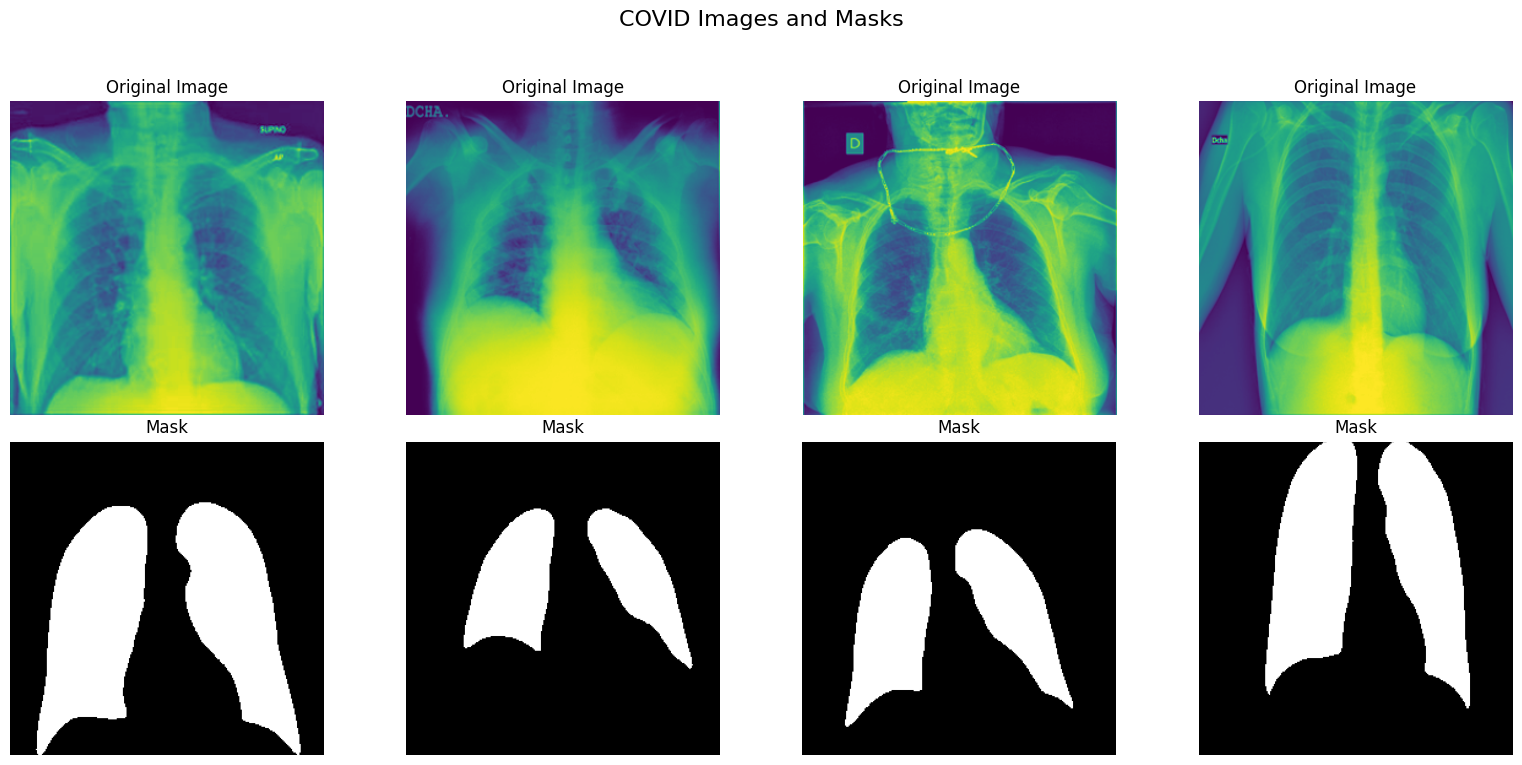


Displaying samples for category: Normal


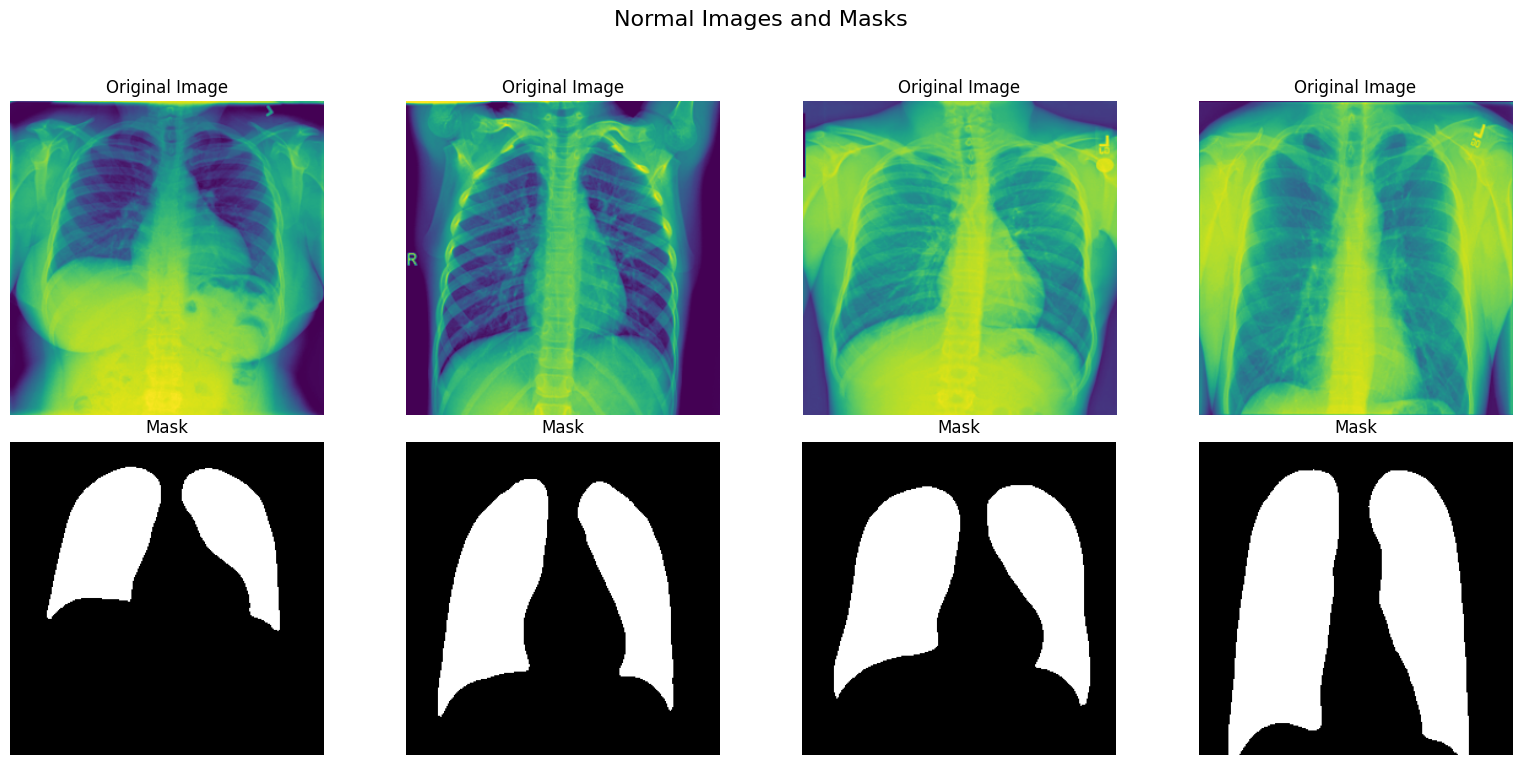


Displaying samples for category: Lung_Opacity


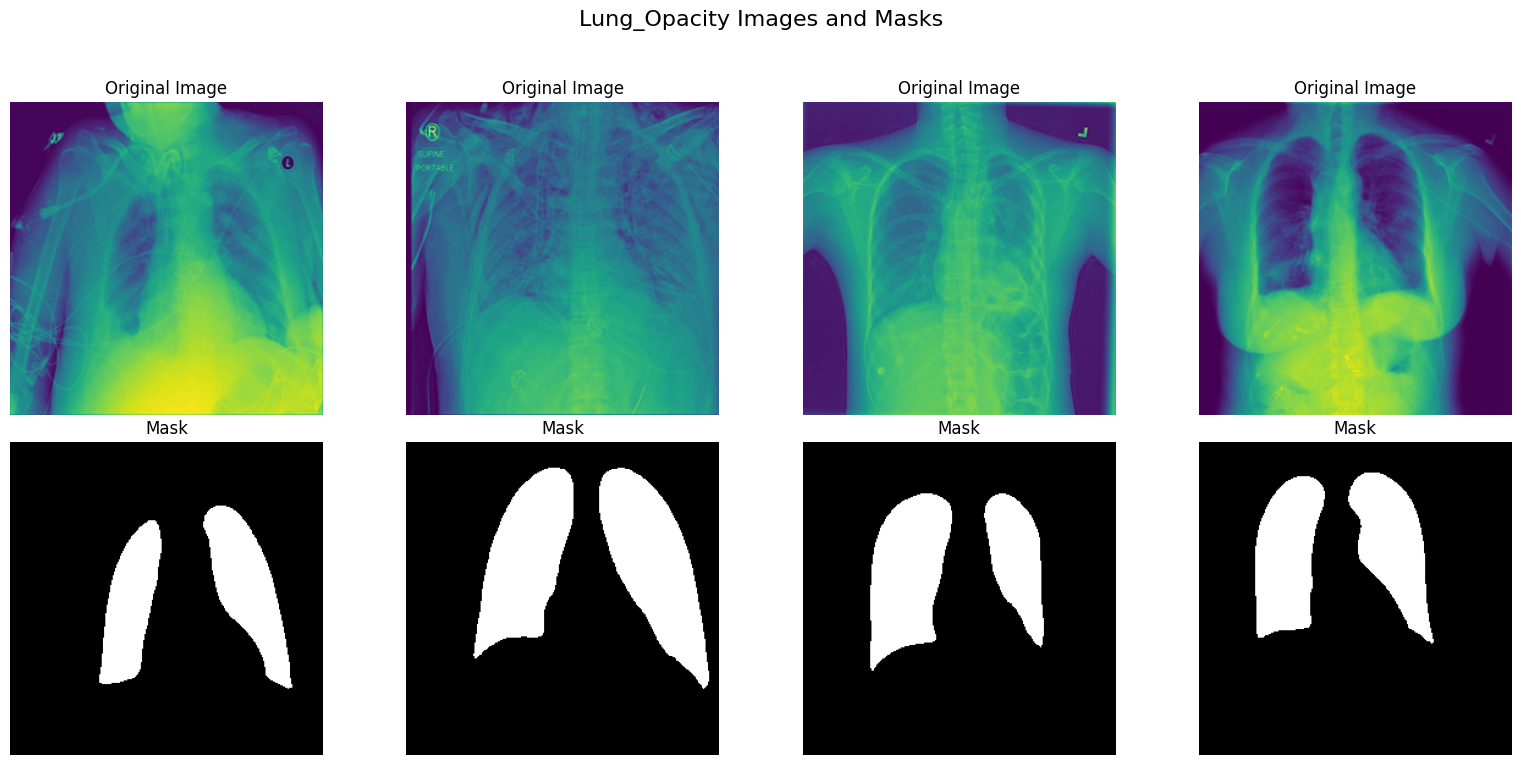


Displaying samples for category: Viral Pneumonia


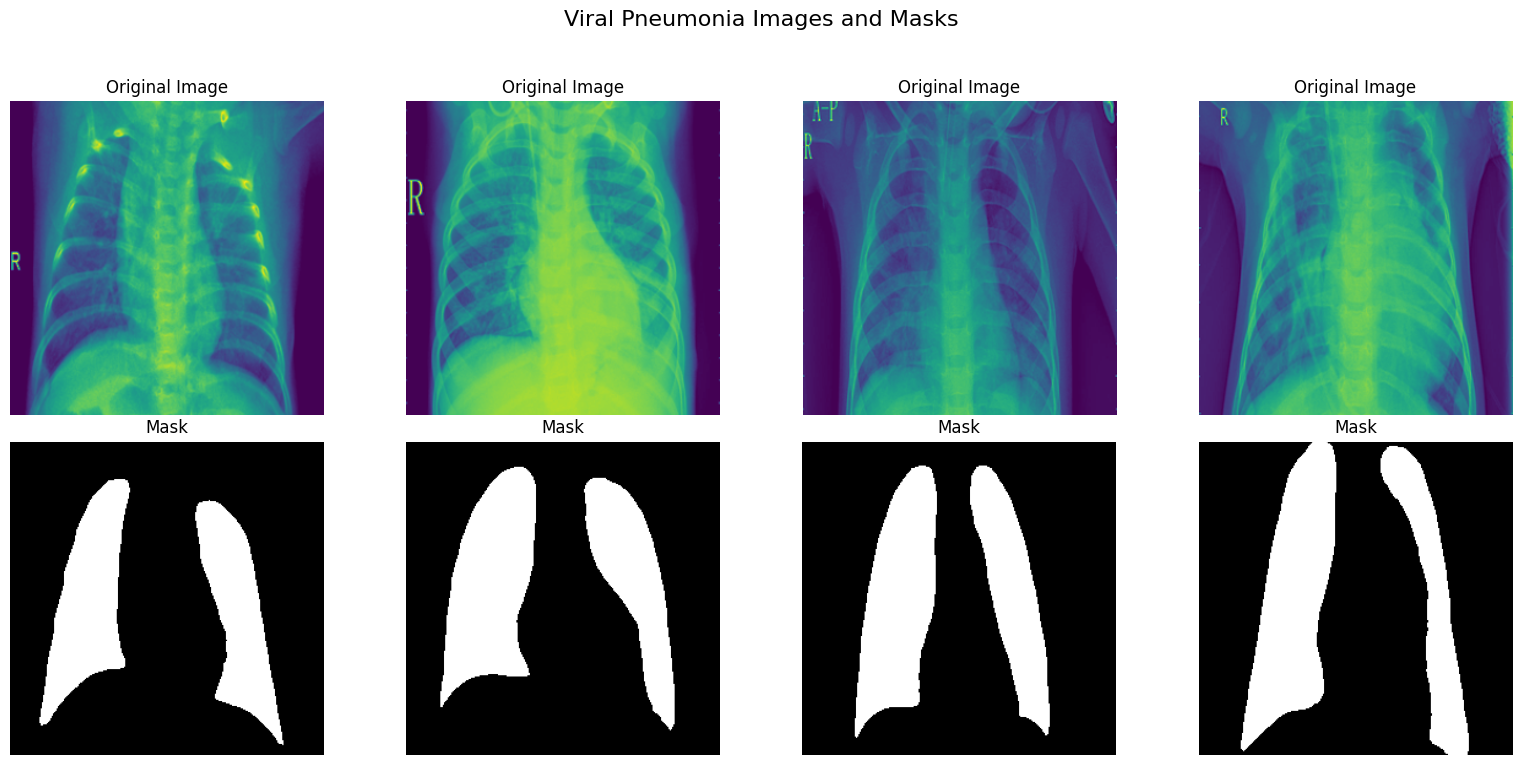

In [5]:
import random
import matplotlib.pyplot as plt
import cv2
import os

# On suppose que 'CATEGORIES' et 'image_paths' ont déjà été définis aux étapes précédentes
# CATEGORIES = ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
# image_paths = { ... dictionnaire rempli ... }

# Boucle sur chaque catégorie pour afficher des exemples d'images et de masques
for category in CATEGORIES:
    print(f"\nDisplaying samples for category: {category}")

    # Récupérer les répertoires des images et des masques pour la catégorie courante
    current_image_dir = image_paths[f'{category}_images']
    current_mask_dir = image_paths[f'{category}_masks']

    # Obtenir la liste de tous les fichiers image dans la catégorie courante
    all_image_files = [
        f for f in os.listdir(current_image_dir)
        if f.endswith(('.png', '.jpg', '.jpeg'))
    ]

    # Sélectionner aléatoirement 4 fichiers image
    # S'assurer de ne pas sélectionner plus de fichiers qu'il n'en existe
    num_samples = min(4, len(all_image_files))
    selected_image_files = random.sample(all_image_files, num_samples)

    # Créer une figure avec une grille 2 x num_samples de sous-graphiques
    fig = plt.figure(figsize=(4 * num_samples, 8))
    fig.suptitle(f'{category} Images and Masks', fontsize=16)

    # # Si aucune image n'est trouvée pour cette catégorie, on peut ignorer l'affichage
    # if num_samples == 0:
    #     print(f"Aucune image trouvée pour la catégorie {category}.")
    #     plt.close(fig)
    #     continue

    for i, img_filename in enumerate(selected_image_files):
        # Construire les chemins complets pour l'image et le masque
        image_path = os.path.join(current_image_dir, img_filename)
        mask_path = os.path.join(current_mask_dir, img_filename)  # On suppose que le masque porte le même nom de fichier

        # Charger l'image
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

        # Charger le masque (s'il existe)
        mask = None
        if os.path.exists(mask_path):
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        else:
            print(f"Warning: Mask not found for {img_filename} in {category}.")

        # Afficher l'image originale sur la première ligne
        plt.subplot(2, num_samples, i + 1)
        plt.imshow(img)
        plt.title('Original Image')
        plt.axis('off')

        # Afficher le masque sur la deuxième ligne
        plt.subplot(2, num_samples, num_samples + i + 1)
        if mask is not None:
            # Les masques sont généralement en niveaux de gris
            plt.imshow(mask, cmap='gray')
            plt.title('Mask')
        else:
            # Afficher un texte si le masque est indisponible
            plt.text(
                0.5, 0.5, 'Mask N/A',
                horizontalalignment='center',
                verticalalignment='center',
                transform=plt.transAxes,
                fontsize=12,
                color='red'
            )
        plt.axis('off')

    # Ajuster la mise en page pour laisser de la place au titre principal
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Task
Prétraitez les images radiographiques en chargeant les images et leurs masques en niveaux de gris, en appliquant les masques pour isoler la région d'intérêt, **sans redimensionner les radiographies** (on garde leur taille native), puis en appliquant l'amélioration du contraste CLAHE. Aplatissez chaque image traitée en un vecteur de caractéristiques 1D et associez-le à son étiquette de catégorie. Standardisez ces vecteurs de caractéristiques avec `StandardScaler` et divisez l'ensemble de données en ensembles d'entraînement et de test. Entraînez un modèle `SVC` avec `PCA` en réutilisant directement les **meilleurs hyperparamètres déjà trouvés dans ce notebook** (`n_components=200`, `C=10`, `gamma='scale'`), **sans GridSearch**. Utilisez une validation croisée `cv=3` et affichez une **learning curve** (scores train/validation macro-F1) pour suivre l'évolution du modèle au fur et à mesure que la taille d'entraînement augmente. Évaluez ensuite les performances finales du classifieur sur l'ensemble de test avec un `classification_report` et une `confusion_matrix`.


## Prétraitement des images et préparation des données

### Subtask:
Charger toutes les images et leurs masques en niveaux de gris, appliquer les masques pour isoler la région d'intérêt, **conserver la taille native des radiographies**, appliquer l'amélioration du contraste CLAHE, puis aplatir chaque image traitée en un vecteur de caractéristiques 1D et l'associer à l'étiquette de catégorie.


**Reasoning**:
The first step is to initialize the lists for features and labels, and create the CLAHE object. This sets up the necessary components before iterating through the images for preprocessing.



In [6]:
features_list = []
labels_list = []

# Créer l'objet CLAHE
clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP_LIMIT, tileGridSize=CLAHE_TILE_SIZE)

print("✅ Listes initialisées et objet CLAHE créé.")

✅ Listes initialisées et objet CLAHE créé.


**Reasoning**:
The next step is to iterate through each category, load images and masks, resize the **mask only if needed** so it matches the image, apply masking, keep the radiography at its native size, apply CLAHE (if `APPLY_CLAHE` is True), flatten the image, and store the resulting feature vector and corresponding label in the previously initialized lists.


**Reasoning**:
The previous code failed because the mask's dimensions did not match the image's dimensions when `cv2.bitwise_and` was called. The fix involves ensuring the mask is resized to the image's dimensions before creating the binary mask and applying the bitwise operation. Additionally, it's beneficial to add a check for non-existent image or mask files to skip them and prevent potential errors, which is already present but will be kept.



In [7]:
observed_shapes = []
skipped_unexpected_shape = 0

for category in CATEGORIES:
    current_image_dir = image_paths[f'{category}_images']
    current_mask_dir = image_paths[f'{category}_masks']

    print(f"Processing {category}...")
    for img_filename in os.listdir(current_image_dir):
        if img_filename.endswith(('.png', '.jpg', '.jpeg')):
            image_path = os.path.join(current_image_dir, img_filename)
            mask_path = os.path.join(current_mask_dir, img_filename)

            img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

            if img is None or mask is None:
                print(f"Warning: Could not load image or mask for {img_filename} in {category}. Skipping.")
                continue

            observed_shapes.append(img.shape)

            # Si les tailles diffèrent, on aligne d'abord le masque sur l'image
            if img.shape != mask.shape:
                mask = cv2.resize(mask, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)

            # Resize mémoire-friendly demandé : 128x128
            if RESIZE_IMAGES:
                img = cv2.resize(img, (TARGET_SIZE, TARGET_SIZE), interpolation=cv2.INTER_AREA)
                mask = cv2.resize(mask, (TARGET_SIZE, TARGET_SIZE), interpolation=cv2.INTER_NEAREST)

            _, binary_mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
            masked_img = cv2.bitwise_and(img, img, mask=binary_mask)

            if APPLY_CLAHE:
                processed_img = clahe.apply(masked_img)
            else:
                processed_img = masked_img

            # float32 pour limiter la RAM
            features_list.append(processed_img.astype(np.float32).flatten())
            labels_list.append(category)

print("✅ Toutes les images ont été traitées.")
print(f"Nombre total de caractéristiques extraites: {len(features_list)}")
print(f"Nombre total d'étiquettes: {len(labels_list)}")
print(f"Formes observées (uniques): {sorted(set(observed_shapes))[:10]}")
print(f"Images ignorées pour forme inattendue: {skipped_unexpected_shape}")
print(f"Taille finale des images utilisées pour le modèle: {TARGET_SIZE}x{TARGET_SIZE}")


Processing COVID...
Processing Normal...
Processing Lung_Opacity...
Processing Viral Pneumonia...
✅ Toutes les images ont été traitées.
Nombre total de caractéristiques extraites: 21165
Nombre total d'étiquettes: 21165
Formes observées (uniques): [(299, 299)]
Images ignorées pour forme inattendue: 0
Taille finale des images utilisées pour le modèle: 128x128


**Reasoning**:
The previous step successfully preprocessed the images and extracted features into lists. The next logical step is to convert these lists into NumPy arrays for efficient processing and compatibility with scikit-learn, and then encode the categorical string labels into numerical format, which is required for machine learning models.



In [8]:
from sklearn.preprocessing import LabelEncoder

# Convertir les listes en tableaux NumPy
X = np.array(features_list, dtype=np.float32)
y_str = np.array(labels_list)

# Encoder les étiquettes de catégorie (chaînes de caractères) en valeurs numériques
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_str)

print(f"✅ Données converties en tableaux NumPy: X.shape={X.shape}, y.shape={y.shape}")
print(f"✅ Étiquettes encodées: {label_encoder.classes_}")
print(f"✅ Type mémoire de X: {X.dtype}")
print(f"✅ Taille approximative de X en RAM: {X.nbytes / (1024**3):.2f} GB")


✅ Données converties en tableaux NumPy: X.shape=(21165, 16384), y.shape=(21165,)
✅ Étiquettes encodées: ['COVID' 'Lung_Opacity' 'Normal' 'Viral Pneumonia']
✅ Type mémoire de X: float32
✅ Taille approximative de X en RAM: 1.29 GB


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

✅ Pipeline PCA + SVC initialisé avec les meilleurs paramètres connus (images 128x128) :
{'pca__n_components': 200, 'svc__C': 10, 'svc__gamma': 'scale'}
✅ Validation croisée : StratifiedKFold(n_splits=3, random_state=42, shuffle=True)

⏳ Calcul de la learning curve (train/validation)...
✅ Learning curve calculée en 813.45 secondes.


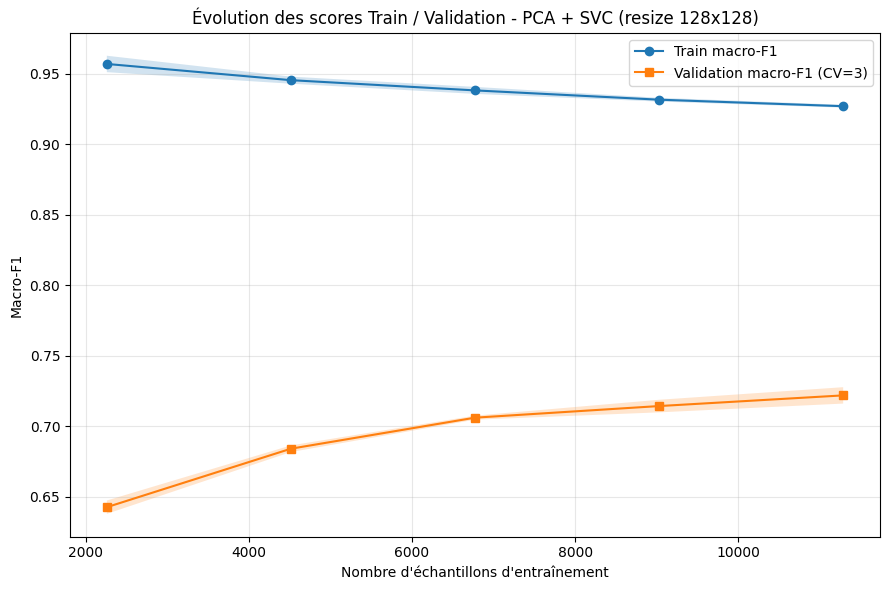


⏳ Début de l'entraînement final du modèle...
✅ Entraînement final terminé en 104.39 secondes.
✅ Prédictions effectuées sur l'ensemble de test.

--- Rapport de Classification ---
              precision    recall  f1-score   support

           0       0.51      0.62      0.56       723
           1       0.75      0.71      0.73      1203
           2       0.85      0.81      0.83      2038
           3       0.89      0.87      0.88       269

    accuracy                           0.75      4233
   macro avg       0.75      0.75      0.75      4233
weighted avg       0.76      0.75      0.76      4233

                 precision    recall  f1-score   support

          COVID       0.51      0.62      0.56       723
   Lung_Opacity       0.75      0.71      0.73      1203
         Normal       0.85      0.81      0.83      2038
Viral Pneumonia       0.89      0.87      0.88       269

       accuracy                           0.75      4233
      macro avg       0.75      0.75      

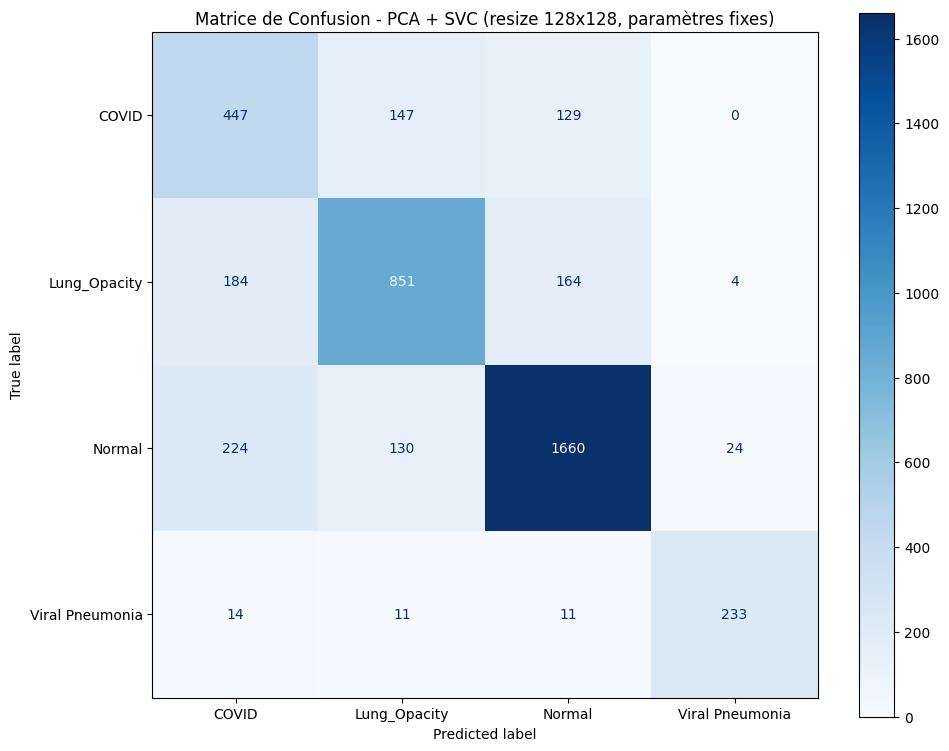

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold, learning_curve
import time

# CV=3 demandé
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

# Meilleurs paramètres déjà trouvés dans le notebook d'origine
best_params = {
    "pca__n_components": 200,
    "svc__C": 10,
    "svc__gamma": "scale"
}

pipe_pca_svc = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=best_params["pca__n_components"], random_state=SEED)),
    ("svc", SVC(
        kernel="rbf",
        class_weight="balanced",
        C=best_params["svc__C"],
        gamma=best_params["svc__gamma"]
    ))
])

print("✅ Pipeline PCA + SVC initialisé avec les meilleurs paramètres connus (images 128x128) :")
print(best_params)
print("✅ Validation croisée :", cv)

# --------------------------------------------------
# 1) Évolution train / validation via learning curve
# --------------------------------------------------
# Remarque : SVC n'a pas d'historique par epoch. La learning curve est la
# manière standard de visualiser la progression train/validation en fonction
# de la taille de l'échantillon d'entraînement.
train_sizes = np.linspace(0.2, 1.0, 5)

print("\n⏳ Calcul de la learning curve (train/validation)...")
start_curve = time.time()

train_sizes_abs, train_scores, val_scores = learning_curve(
    estimator=pipe_pca_svc,
    X=X_train,
    y=y_train,
    train_sizes=train_sizes,
    cv=cv,
    scoring="f1_macro",
    n_jobs=1,
    shuffle=True,
    random_state=SEED
)

curve_time = time.time() - start_curve

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

print(f"✅ Learning curve calculée en {curve_time:.2f} secondes.")

plt.figure(figsize=(9, 6))
plt.plot(train_sizes_abs, train_mean, marker='o', label='Train macro-F1')
plt.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std, alpha=0.2)

plt.plot(train_sizes_abs, val_mean, marker='s', label='Validation macro-F1 (CV=3)')
plt.fill_between(train_sizes_abs, val_mean - val_std, val_mean + val_std, alpha=0.2)

plt.title("Évolution des scores Train / Validation - PCA + SVC (resize 128x128)")
plt.xlabel("Nombre d'échantillons d'entraînement")
plt.ylabel("Macro-F1")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 2) Entraînement final sur tout le train
# --------------------------------------------------
print("\n⏳ Début de l'entraînement final du modèle...")
start_time = time.time()

pipe_pca_svc.fit(X_train, y_train)

training_time = time.time() - start_time
print(f"✅ Entraînement final terminé en {training_time:.2f} secondes.")

# --------------------------------------------------
# 3) Prédictions et sorties de classification
# --------------------------------------------------
y_pred = pipe_pca_svc.predict(X_test)
print("✅ Prédictions effectuées sur l'ensemble de test.")

print("\n--- Rapport de Classification ---")
print(classification_report(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

cm = confusion_matrix(y_test, y_pred)

print("\n--- Matrice de Confusion ---")
fig, ax = plt.subplots(figsize=(10, 8))
cmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
cmd.plot(ax=ax, cmap=plt.cm.Blues, values_format='d')
ax.set_title('Matrice de Confusion - PCA + SVC (resize 128x128, paramètres fixes)')
plt.tight_layout()
plt.show()
